# Sign Language Recognition

#Purpose:

Developed an end-to-end machine learning pipeline to classify 24 distinct hand gestures from the Sign Language MNIST dataset ($28 \times 28$ grayscale images).


# Creating a big picture of the project.

# Basic problem properties

By analyzing the problem constraints and the nature of the dataset, we can define the project's scope through the following properties:

1. Problem Definition
The objective is a Multiclass Classification task. Given a flattened 784-pixel input, the model must map the features to one of 24 discrete classes, each representing a specific letter in Sign Language.

2. Candidate Models & Rationale
To find the optimal boundary for these hand gestures, we consider several algorithmic approaches, categorized by their underlying logic:

A. Linear & Geometric Models (The Baselines)
Logistic Regression (Logit): Serves as the primary baseline to test the linear separability of the pixel data.

Support Vector Machine (SVM): The core focus of this project. SVMs are highly effective in high-dimensional spaces (784 features) and utilize the "Kernel Trick" (RBF, Polynomial) to find non-linear boundaries between complex hand shapes.

B. Tree-Based Models (Non-Linear & Robust)
Decision Trees: Useful for identifying simple hierarchical rules in the data, though often prone to overfitting on raw image pixels.

Random Forest & Extra-Trees: Ensemble "Bagging" methods that reduce variance by averaging multiple deep trees. These are robust to noise and help manage the high correlation between neighboring pixels.

C. Boosting Methods (Iterative Optimization)
AdaBoost: Focuses on "hard-to-classify" samples by weight-adjusting based on the errors of previous iterations.

Gradient Boosting (XGBoost, LightGBM): Frequently the state-of-the-art for tabular and flattened pixel data. It minimizes a loss function iteratively to capture subtle differences between similar signs (e.g., 'M' vs. 'N').

D. Ensemble Meta-Learners
Stacking: A sophisticated architecture that uses a "meta-model" to aggregate the predictions of several base learners (e.g., combining SVM, Random Forest, and Logit). This approach leverages the unique strengths of each model to produce a more generalized final prediction.


#Model selection

SVM was selected as the optimal model because sign language recognition is fundamentally a geometric boundary problem. Since hand gestures are defined by complex, non-linear shapes, the SVM’s 'Kernel Trick' allows us to map 784-pixel dimensions into a space where these gestures can be separated by a Maximum Margin Hyperplane. This mathematical approach provides superior generalization and precision in distinguishing between visually similar signs compared to linear or tree-based models.

# Load necessary Librarys

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve
import kagglehub as kh
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.dummy import DummyClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Load the data set


In [3]:
path = kh.dataset_download("datamunge/sign-language-mnist")

Using Colab cache for faster access to the 'sign-language-mnist' dataset.


# Split the data in training and test set


In [4]:
X_train = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv')
y_train = X_train['label']
X_train = X_train.drop('label', axis=1)

X_test = pd.read_csv('/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv')
y_test = X_test['label']
X_test = X_test.drop('label', axis=1)


# Familiarize with the dataset

# A first look at the data

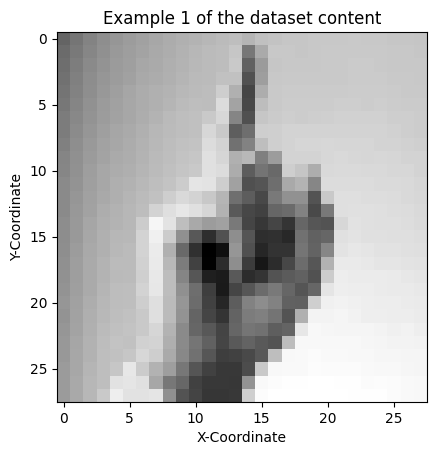

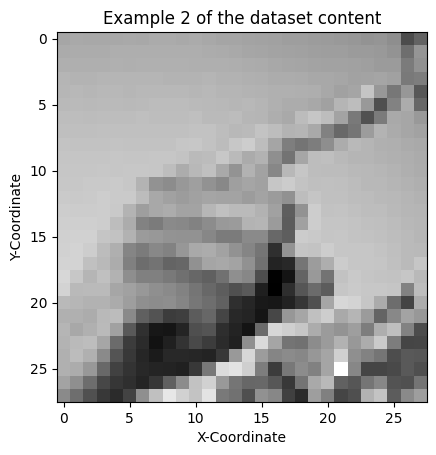

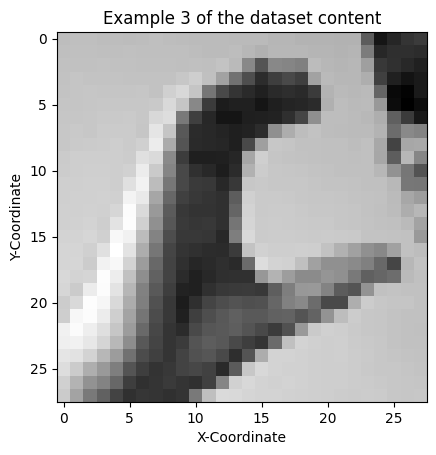

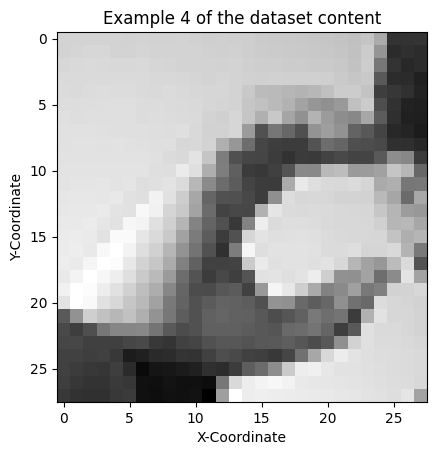

In [5]:
# Define the number of examples that you want to see
k = 4

for i in range(k):
  plt.title(f'Example {i+1} of the dataset content')
  plt.xlabel('X-Coordinate')
  plt.ylabel('Y-Coordinate')
  plt.imshow(X_train.iloc[i].values.reshape(28, 28), cmap='gray')
  plt.show()

#Look for missing values or data anomalies

When dealing with any data its important to look for missing values or data anomalies, so we can guarantee data integrity and thus a better model performance.

#Reuslts

After looking data, we conclude there's no problem with data, so we can use it safely.

In [6]:
# Resume of training data

# Number of features
print(f'Number of features: {X_train.shape[1]}')
# Number of instances
print(f'Number of training instances: {X_train.shape[0]}')
# Numerical variables
print(f'Number of numerical variables: {X_train.select_dtypes(include=[np.number]).shape[1]}')
#Number of categorical variables
print(f'Number of categorical variables: {X_train.select_dtypes(include=[object]).shape[1]}')
#The number of missing values
print(f'Number of missing values: {X_train.isnull().sum().sum()}')
#Number of test instances
print(f'Number of test instances: {X_test.shape[0]}')
#Number of labels
print(f'Number of labels: {y_train.nunique()}')


Number of features: 784
Number of training instances: 27455
Number of numerical variables: 784
Number of categorical variables: 0
Number of missing values: 0
Number of test instances: 7172
Number of labels: 24


#Check for class imbalance

Most classification problems present class imbalance and as a quick prevention we construct a df that contain every single class proporiton so we can search for class imbalance in the data.

#Results
Since class proportions looks well, we can trust in accuracy as our gold standard measure and using precision and recall to debug model mistakes.

In [7]:
class_df = y_train.value_counts().reset_index()
class_df['proportion'] = class_df['count']/class_df['count'].sum()
class_df

,label,count,proportion
0,17,1294,0.047132
1,16,1279,0.046585
2,11,1241,0.045201
3,22,1225,0.044618
4,5,1204,0.043854
5,18,1199,0.043671
6,14,1196,0.043562
7,3,1196,0.043562
8,19,1186,0.043198
9,23,1164,0.042397


# Preprocessing pipeline


# Elements to consider in the preprocessing

Since our choosen model is SVM, it is important to guarantee data satisfy model's assumptions such as:

1. Data is scaled: Since SVM tries to find widest margin between classes using euclidian distances while reduce margin violations, different scales in data might affect correct model learning.
2. Data is not redundant : While SVMs are mathematically capable of handling high-dimensional data, they face a significant increase in training time complexity—often $O(n^2 \times m)$ or higher depending on the kernel. To optimize this, we implement Principal Component Analysis (PCA) so the model can learn just about the most important features.
3. While PCA is an unsupervised technique that captures the directions of maximum variance, it is "class-blind." It might prioritize variance caused by background noise or lighting that does not help distinguish between specific hand signs. To optimize the input for our SVM, we apply LDA as a supervised dimensionality reduction step. LDA specifically aims to maximize class separability by finding a projection that maximizes the distance between the means of the 24 different classes (Between-Class Variance) while minimizing the spread within each individual class (Within-Class Variance)

In [26]:
#Establish the degree of the polynomial

preprocessing_pipe = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components =  0.80)),
        ('lda', LDA())

    ])

# Complete Pipeline

In [27]:
full_pipe = Pipeline(
    steps = [
        ('preprocessing', preprocessing_pipe),
        ('model', SVC(probability= True))
    ]
)

# Define a gird of SVM Classifier model

 # Selecting proper parameters

Optimized a Support Vector Machine (SVM) model by implementing a Polynomial Kernel restricted to degree 1 and a small $C$ parameter. This strategy prioritized structural regularization and a soft margin, resulting in a wider decision boundary and superior generalization on unseen data. Further refinement with a low learning rate ensured stable convergence and a robust, smooth decision model.

In [28]:
svc_parameters = [
    {
        # RBF is usually the winner for MNIST.
        # Reducing Gamma and C steps to the most likely 'sweet spots'.
        'model__kernel': ['rbf'],
        'model__gamma': [0.01, 'scale'],
        'model__C': [0.1,10,1]
    },
    {
        # Linear kernel is MUCH faster than Poly.
        # For many features, a simple linear boundary is often sufficient.
        'model__kernel': ['linear'],
        'model__C': [0.1, 1,10]
    }
]

#Gird search for find best parameters

In [29]:
gird_search = GridSearchCV(
    full_pipe,
    svc_parameters,
    cv= 3,
    scoring = 'accuracy'
)

# Fit the model

In [30]:
gird_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('scaler',
                                                         StandardScaler()),
                                                        ('pca',
                                                         PCA(n_components=0.8)),
                                                        ('lda',
                                                         LinearDiscriminantAnalysis())])),
                                       ('model', SVC(probability=True))]),
             param_grid=[{'model__C': [0.1, 10, 1],
                          'model__gamma': [0.01, 'scale'],
                          'model__kernel': ['rbf']},
                         {'model__C': [0.1, 1, 10],
                          'model__kernel': ['linear']}],
             scoring='accuracy')

# Select the best model

In [31]:
best_model = gird_search.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('scaler', StandardScaler()),
                                 ('pca', PCA(n_components=0.8)),
                                 ('lda', LinearDiscriminantAnalysis())])),
                ('model', SVC(C=10, probability=True))])

# Test best model performance

# Confusion Matrix

In [32]:
y_train_pred = best_model.predict(X_train)
M = confusion_matrix(y_train, y_train_pred)

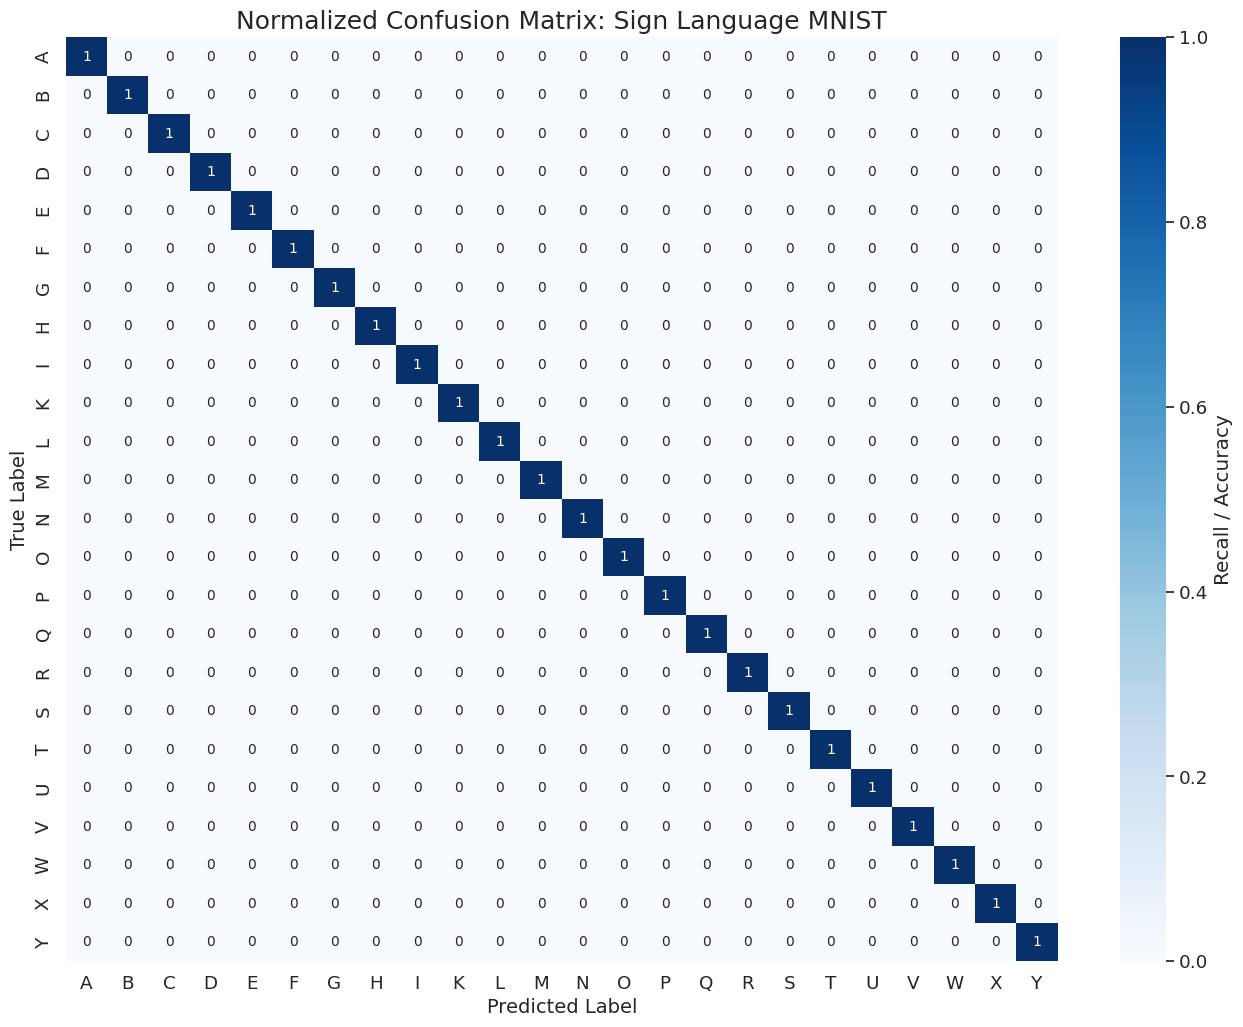


--- Top Misclassification Errors ---


In [33]:

#Alphabet mapping
alphabet = "ABCDEFGHIKLMNOPQRSTUVWXY"
label_map = {i: letter for i, letter in enumerate(alphabet)}

#Normalize and Create DataFrame with Letter Labels
M_norm = M.astype('float') / M.sum(axis=1)[:, np.newaxis]
df_cm_norm = pd.DataFrame(M_norm, index=[label_map[i] for i in range(24)],
                               columns=[label_map[i] for i in range(24)])

#Plotting the Heatmap
plt.figure(figsize=(16, 12))
sns.set(style="white", font_scale=1.2)
sns.heatmap(df_cm_norm, annot=True, cmap="Blues",
            annot_kws={"size": 10}, cbar_kws={'label': 'Recall / Accuracy'})
plt.title("Normalized Confusion Matrix: Sign Language MNIST", fontsize=18)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.show()

# Automated Error Diagnosis
print("\n--- Top Misclassification Errors ---")
# Zero out the diagonal (correct predictions) to find the errors
errors = df_cm_norm.copy()
np.fill_diagonal(errors.values, 0)

# Get the top 5 most frequent misclassifications
top_errors = errors.unstack().sort_values(ascending=False).head(5)
for (pred, true), val in top_errors.items():
    if val > 0:
        print(f"True: {true} | Predicted: {pred} | Error Rate: {val:.4f}")

# Looking for Misclassification errors

After look at the Confussion matix, we were able to identify that model misclassification errors come from letters V and U, G and T, V and R, and U and R.

# Visualizing the misclassifcation errors

In [34]:
#Create a mapping for readability (Sign Language MNIST skips J and Z)
alphabet = "ABCDEFGHIKLMNOPQRSTUVWXY"
label_map = {i: letter for i, letter in enumerate(alphabet)}

#Find the indices where the model made a mistake
misclassified_indices = np.where(y_train_pred != y_train)[0]

# Plot the first 10 errors to keep the notebook clean
plt.figure(figsize=(15, 6))
for i, idx in enumerate(misclassified_indices[:10]):
    plt.subplot(2, 5, i + 1)

    # Reshape the flattened pixels back to 28x28
    img = X_train.iloc[idx].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')

    # Get the True and Predicted letters
    true_letter = label_map[y_train.iloc[idx]]
    pred_letter = label_map[y_train_pred[idx]]

    plt.title(f"True: {true_letter} | Pred: {pred_letter}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Total misclassified examples in training set: {len(misclassified_indices)}")


<Figure size 1500x600 with 0 Axes>

Total misclassified examples in training set: 0


# Precision and Recall score

In [35]:

prec = precision_score(y_train, y_train_pred, average='weighted')
rec = recall_score(y_train, y_train_pred, average='weighted')

print(f'Precision score: {prec:.4f}')
print(f'Recall score: {rec:.4f}')

Precision score: 1.0000
Recall score: 1.0000


# Accuracy performance

In [36]:

best_model_score = cross_val_score(best_model, X_train, y_train, cv = 3, scoring = 'accuracy')
print(f'Accuracy score: {best_model_score.mean()}')

Accuracy score: 1.0


# ROC performance

In [37]:
best_model_auc = cross_val_score(best_model, X_train, y_train, cv = 3, scoring = 'roc_auc_ovr')
print(f'ROC score: {best_model_auc.mean()}')

ROC score: 1.0


# Dumb model implementation

In [38]:
dumb_model = DummyClassifier(strategy='most_frequent')
dumb_model.fit(X_train, y_train)
dumb_model_pred = dumb_model.predict(X_train)
dumb_model_score = cross_val_score(dumb_model, X_train, y_train, cv = 5, scoring = 'accuracy')
print(f'Accuracy score: {dumb_model_score.mean()}')

Accuracy score: 0.04713167000546349


# Dumb model Roc Score

In [39]:
dumb_model_auc_score = cross_val_score(dumb_model, X_train, y_train, cv = 5, scoring = 'roc_auc_ovr')
print(f'ROC score: {dumb_model_auc_score.mean()}')

ROC score: 0.5


# Model Learning Curve

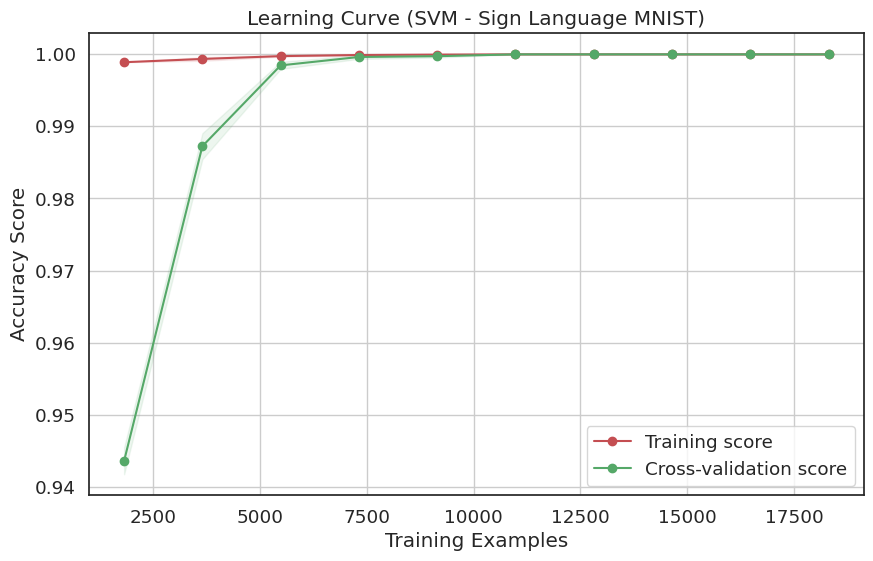

In [40]:

# Generar la curva de aprendizaje
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv = 3,
    scoring = 'accuracy',
    n_jobs = -1 # Para acelerar el proceso usando todos los núcleos
)

# Calcular promedios y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Crear el gráfico
plt.figure(figsize=(10, 6))
plt.plot(train_sizes_abs, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes_abs, test_mean, 'o-', color="g", label="Cross-validation score")

# Rellenar la varianza para ver la estabilidad
plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve (SVM - Sign Language MNIST)")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Comparison of both model's performance

# SVM performance in test set

In [41]:
test_accuracy = best_model.score(X_test, y_test)
print(f'Accuracy en el set de prueba: {test_accuracy:.4f}')

Accuracy en el set de prueba: 0.8956


# Dumb model performance in test set

In [42]:
dumb_model_test_accuracy = dumb_model.score(X_test, y_test)
print(f'Accuracy en el set de prueba: {dumb_model_test_accuracy:.4f}')

Accuracy en el set de prueba: 0.0201


# Conclusion
The performance of SVM was significantly better than the Dummy classifier, proving that our model is really learning.